In [2]:
import matplotlib
import matplotlib.pyplot as plt

print(f"matplotlib version: {matplotlib.__version__}")

matplotlib version: 3.10.8


### 1. 2 ways of creating plots

[]

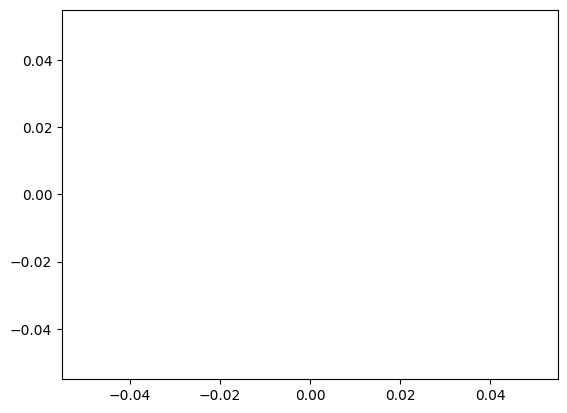

In [3]:
plt.plot()

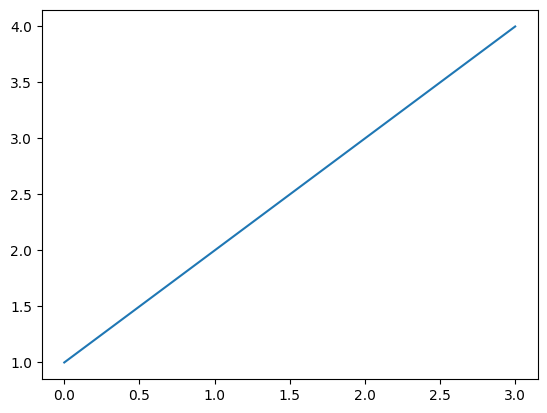

In [4]:
plt.plot([1, 2, 3, 4]);

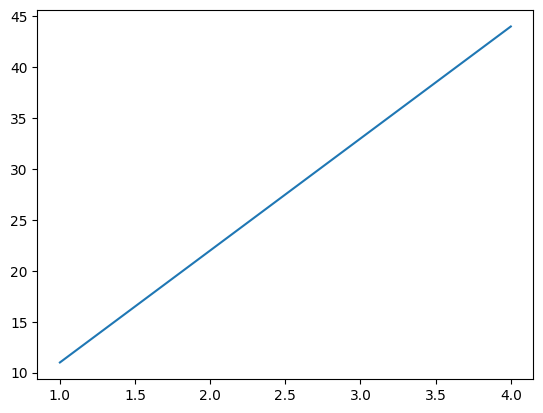

In [5]:
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

plt.plot(x,y)

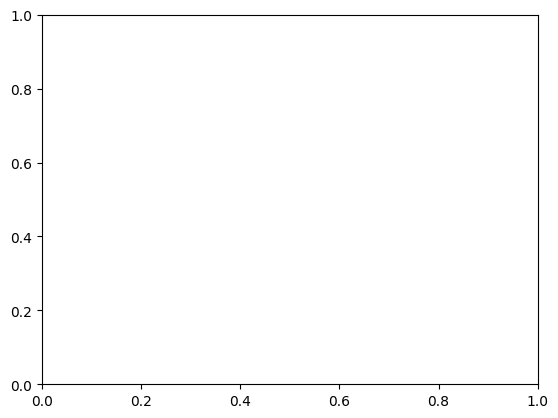

In [6]:
fig = plt.figure() # create a figure
ax = fig.add_subplot() # add an axes 
plt.show()

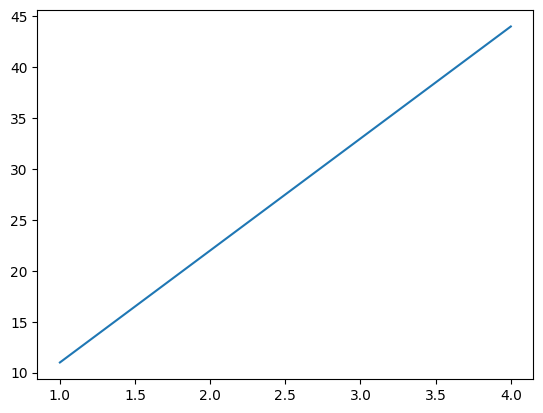

In [8]:
fig, ax = plt.subplots()
ax.plot(x, y);

In [9]:
type(fig), type(ax)

(matplotlib.figure.Figure, matplotlib.axes._axes.Axes)

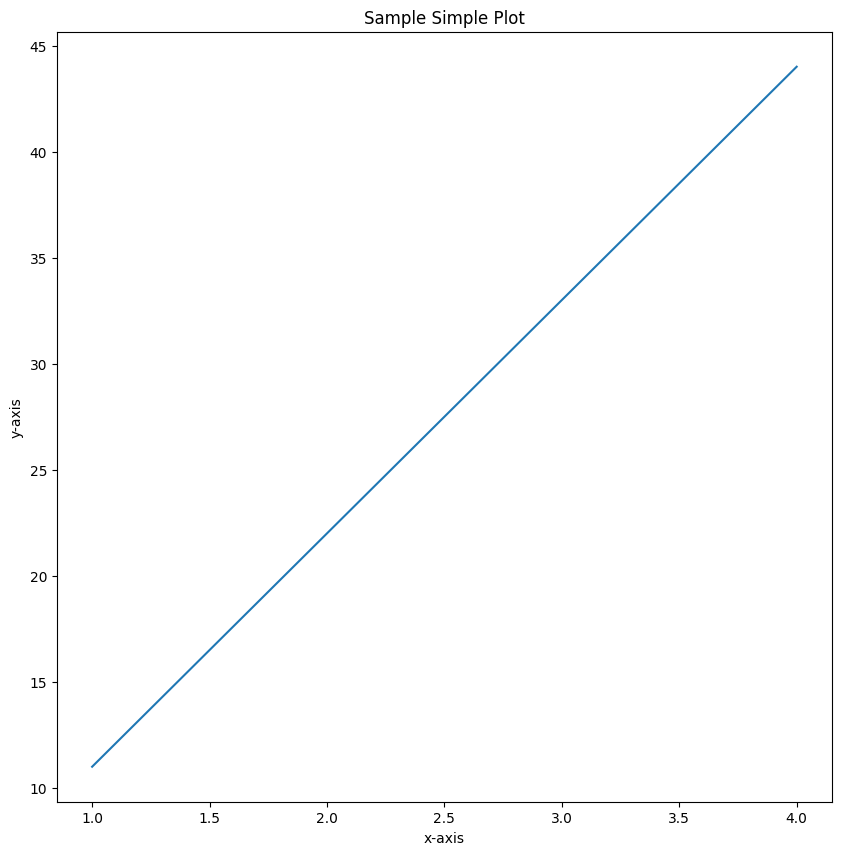

In [10]:
# A matplotlib workflow

# 0. Import and get matplotlib ready
# %matplotlib inline # Not necessary in newer versions of Jupyter (e.g. 2022 onwards)
import matplotlib.pyplot as plt

# 1. Prepare data
x = [1, 2, 3, 4]
y = [11, 22, 33, 44]

# 2. Setup plot (Figure and Axes)
fig, ax = plt.subplots(figsize=(10,10))

# 3. Plot data
ax.plot(x, y)

# 4. Customize plot
ax.set(title="Sample Simple Plot", xlabel="x-axis", ylabel="y-axis")

# 5. Save & show
fig.savefig("data/simple-plot.png")

### 2. Making the most common type of plots using NumPy arrays

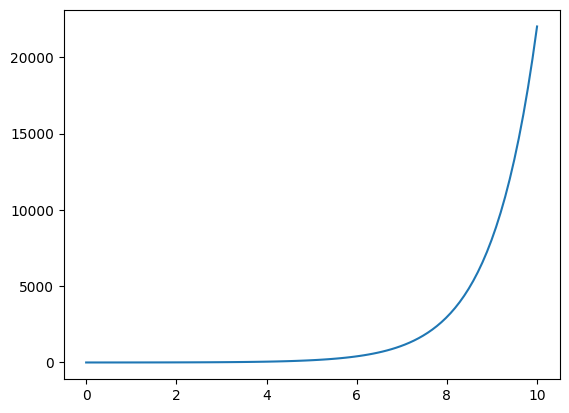

In [15]:
import numpy as np
x = np.linspace(0, 10, 100)

# The default plot is line
fig, ax = plt.subplots()
ax.plot(x, np.exp(x));

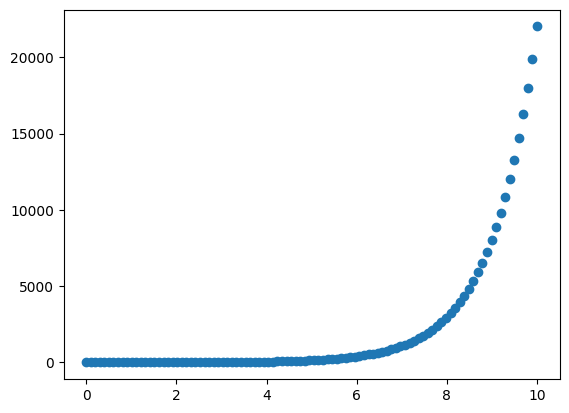

In [16]:
# Need to recreate our figure and axis instances when we want a new figure
fig, ax = plt.subplots()
ax.scatter(x, np.exp(x));

[Text(0.5, 1.0, "Dan's Nut Butter Store"), Text(0, 0.5, 'Price ($)')]

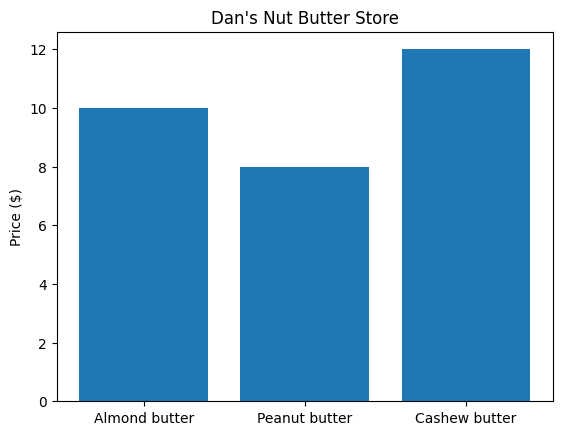

In [20]:
# You can make plots from a dictionary
nut_butter_prices = {"Almond butter": 10,
                     "Peanut butter": 8,
                     "Cashew butter": 12}
fig, ax = plt.subplots()
ax.bar(nut_butter_prices.keys(), nut_butter_prices.values())
ax.set(title="Dan's Nut Butter Store", ylabel="Price ($)")

<BarContainer object of 3 artists>

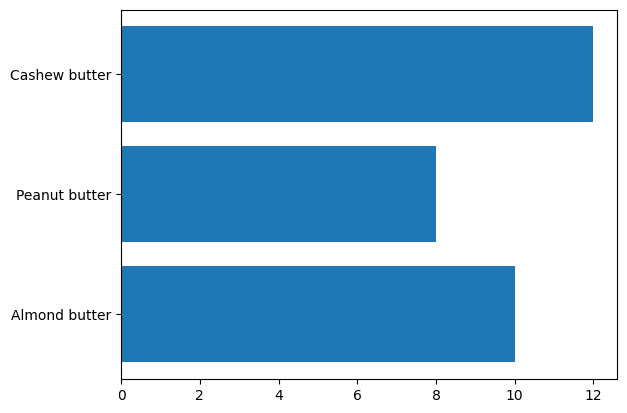

In [23]:
fig, ax = plt.subplots()
ax.barh( nut_butter_prices.keys(), nut_butter_prices.values())

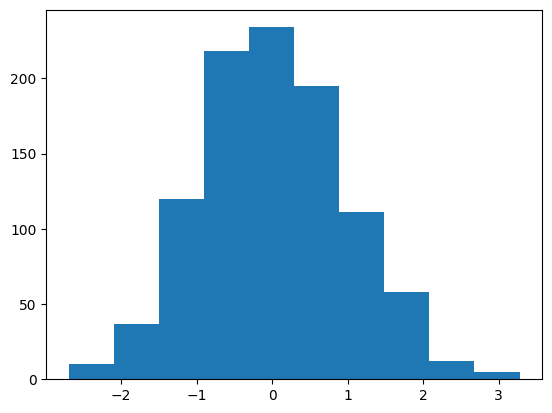

In [25]:
# Make some data from a normal distribution
x = np.random.randn(1000)

fig, ax = plt.subplots()
ax.hist(x);

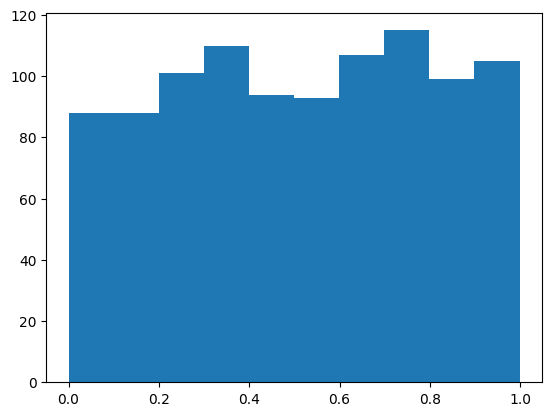

In [38]:
x = np.random.random(1000)

fig, ax = plt.subplots()
ax.hist(x);

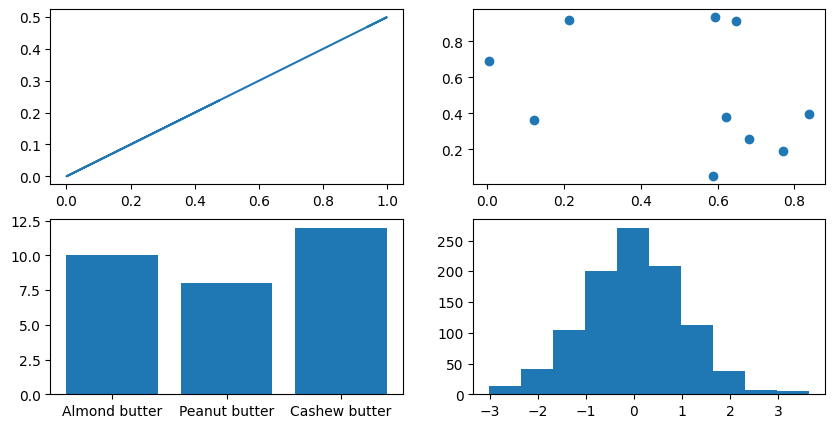

In [40]:
# Option 1: Create 4 subplots with each Axes having its own variable name
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Plot data to each axis
ax1.plot(x, x/2);
ax2.scatter(np.random.random(10), np.random.random(10));
ax3.bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax4.hist(np.random.randn(1000));

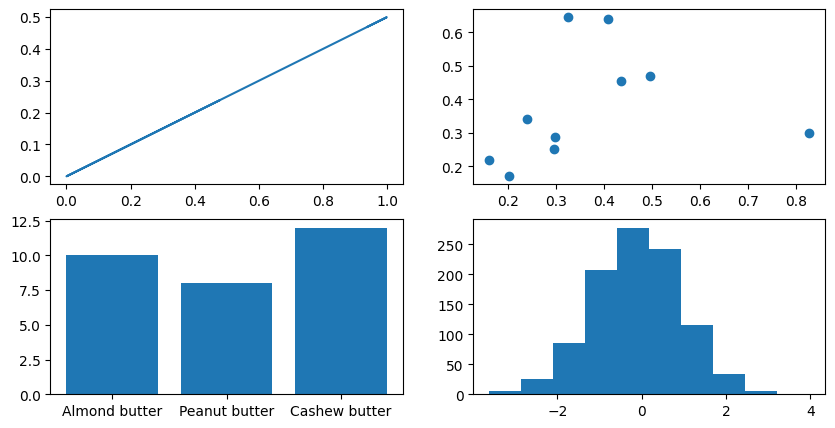

In [41]:
# Option 2: Create 4 subplots with a single ax variable
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 5))

# Index the ax variable to plot data
ax[0, 0].plot(x, x/2);
ax[0, 1].scatter(np.random.random(10), np.random.random(10));
ax[1, 0].bar(nut_butter_prices.keys(), nut_butter_prices.values());
ax[1, 1].hist(np.random.randn(1000));

### 3. Plotting data directly with pandas

In [42]:
import pandas as pd

In [43]:
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales.csv") # load data from raw URL (original: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/car-sales.csv)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,"$4,000.00"
1,Honda,Red,87899,4,"$5,000.00"
2,Toyota,Blue,32549,3,"$7,000.00"
3,BMW,Black,11179,5,"$22,000.00"
4,Nissan,White,213095,4,"$3,500.00"
5,Toyota,Green,99213,4,"$4,500.00"
6,Honda,Blue,45698,4,"$7,500.00"
7,Honda,Blue,54738,4,"$7,000.00"
8,Toyota,White,60000,4,"$6,250.00"
9,Nissan,White,31600,4,"$9,700.00"


In [61]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2025', periods=1000))
ts

2025-01-01    0.277041
2025-01-02   -0.950275
2025-01-03    0.177903
2025-01-04    1.050834
2025-01-05   -0.726276
                ...   
2027-09-23    1.644655
2027-09-24    0.975680
2027-09-25   -0.553962
2027-09-26    1.785670
2027-09-27   -0.048129
Freq: D, Length: 1000, dtype: float64

<Axes: >

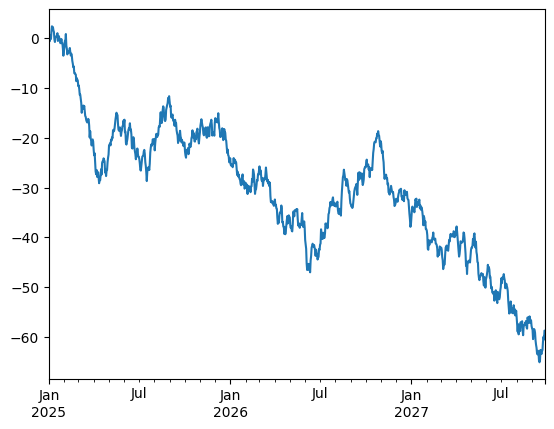

In [62]:
ts.cumsum().plot(kind='line')

In [64]:
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales.csv")

# Remove price column symbols
car_sales["Price"] = car_sales["Price"].str.replace('[$,.]', '', regex=True)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,400000
1,Honda,Red,87899,4,500000
2,Toyota,Blue,32549,3,700000
3,BMW,Black,11179,5,2200000
4,Nissan,White,213095,4,350000
5,Toyota,Green,99213,4,450000
6,Honda,Blue,45698,4,750000
7,Honda,Blue,54738,4,700000
8,Toyota,White,60000,4,625000
9,Nissan,White,31600,4,970000


In [65]:
# Remove last two zeros
car_sales["Price"] = car_sales["Price"].str[:-2]
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,Toyota,Blue,32549,3,7000
3,BMW,Black,11179,5,22000
4,Nissan,White,213095,4,3500
5,Toyota,Green,99213,4,4500
6,Honda,Blue,45698,4,7500
7,Honda,Blue,54738,4,7000
8,Toyota,White,60000,4,6250
9,Nissan,White,31600,4,9700


In [66]:
# Add a date column
car_sales["Sale Date"] = pd.date_range("1/1/2024", periods=len(car_sales))
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date
0,Toyota,White,150043,4,4000,2024-01-01
1,Honda,Red,87899,4,5000,2024-01-02
2,Toyota,Blue,32549,3,7000,2024-01-03
3,BMW,Black,11179,5,22000,2024-01-04
4,Nissan,White,213095,4,3500,2024-01-05
5,Toyota,Green,99213,4,4500,2024-01-06
6,Honda,Blue,45698,4,7500,2024-01-07
7,Honda,Blue,54738,4,7000,2024-01-08
8,Toyota,White,60000,4,6250,2024-01-09
9,Nissan,White,31600,4,9700,2024-01-10


In [67]:
car_sales["Total Sales"] = car_sales["Price"].astype(int).cumsum()
car_sales

,Make,Colour,Odometer (KM),Doors,Price,Sale Date,Total Sales
0,Toyota,White,150043,4,4000,2024-01-01,4000
1,Honda,Red,87899,4,5000,2024-01-02,9000
2,Toyota,Blue,32549,3,7000,2024-01-03,16000
3,BMW,Black,11179,5,22000,2024-01-04,38000
4,Nissan,White,213095,4,3500,2024-01-05,41500
5,Toyota,Green,99213,4,4500,2024-01-06,46000
6,Honda,Blue,45698,4,7500,2024-01-07,53500
7,Honda,Blue,54738,4,7000,2024-01-08,60500
8,Toyota,White,60000,4,6250,2024-01-09,66750
9,Nissan,White,31600,4,9700,2024-01-10,76450


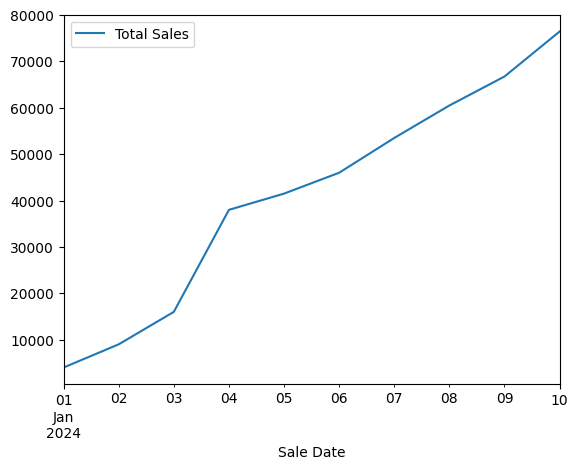

In [68]:
car_sales.plot(x='Sale Date', y='Total Sales');

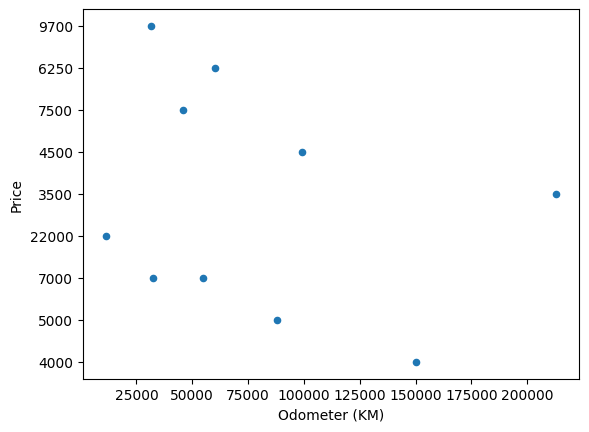

In [70]:
car_sales["Price"] = car_sales["Price"].astype(str)

# Plot a scatter plot
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter");

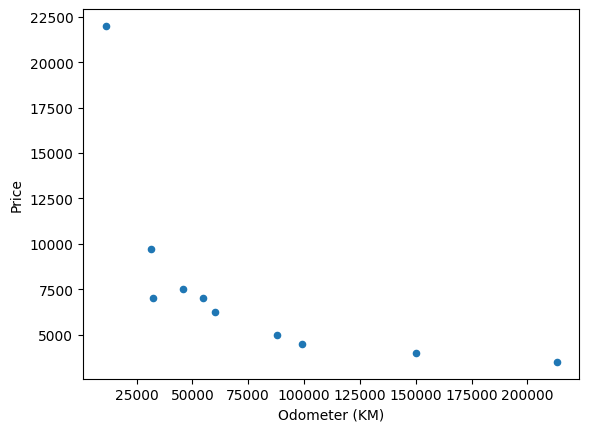

In [73]:
car_sales["Price"] = car_sales["Price"].astype(int)

# Plot a scatter plot
car_sales.plot(x="Odometer (KM)", y="Price", kind='scatter');

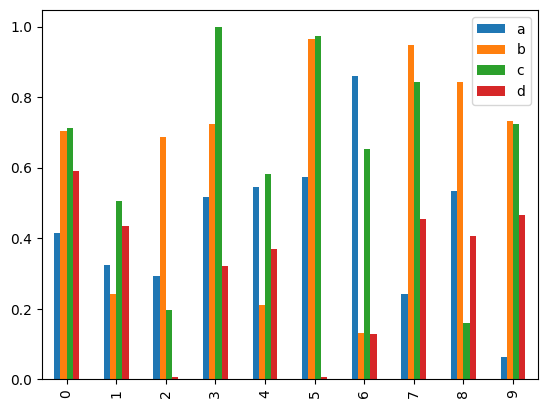

In [74]:
x = np.random.rand(10, 4)
df = pd.DataFrame(x, columns=['a', 'b', 'c', 'd'])
df.plot.bar();

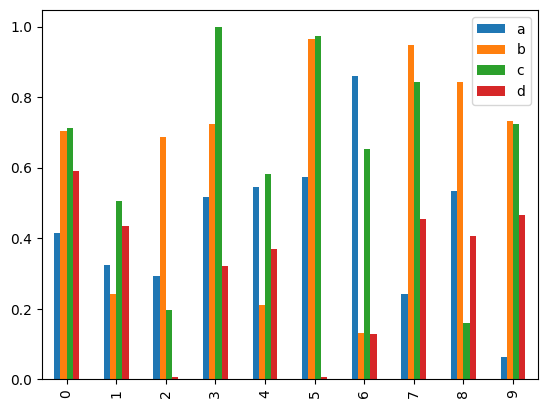

In [75]:
df.plot(kind='bar');

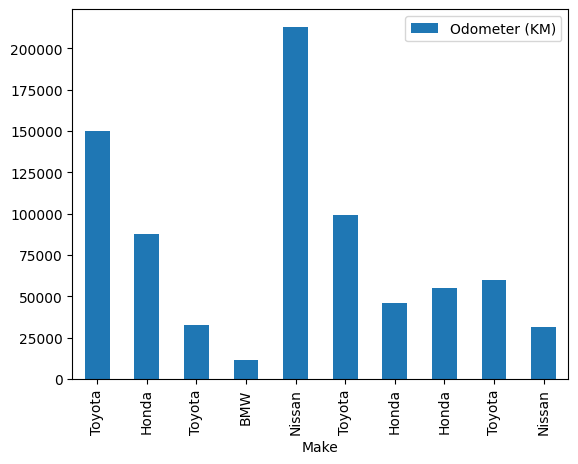

In [76]:
car_sales.plot(x="Make", y="Odometer (KM)", kind="bar");

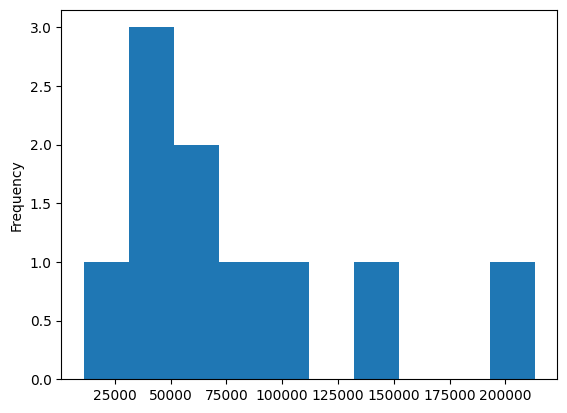

In [78]:
# car_sales["Odometer (KM)"].plot(kind="hist");
car_sales["Odometer (KM)"].plot.hist(bins=10);

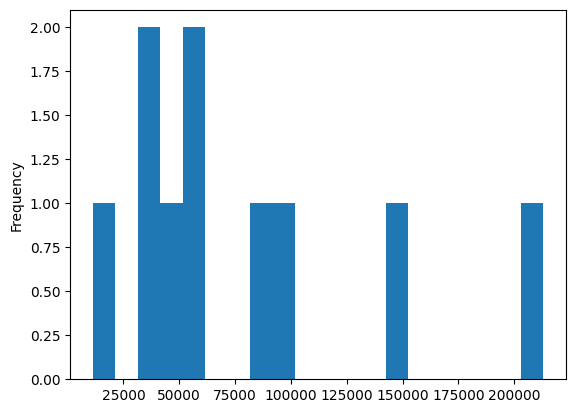

In [79]:
car_sales["Odometer (KM)"].plot.hist(bins=20);

In [80]:
heart_disease = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/heart-disease.csv") # load directly from raw URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/heart-disease.csv)
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


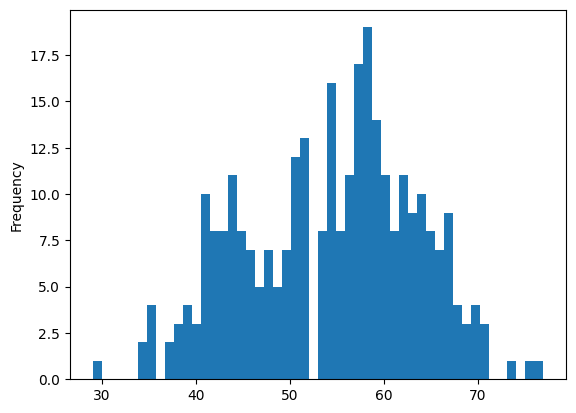

In [81]:
heart_disease["age"].plot.hist(bins=50);

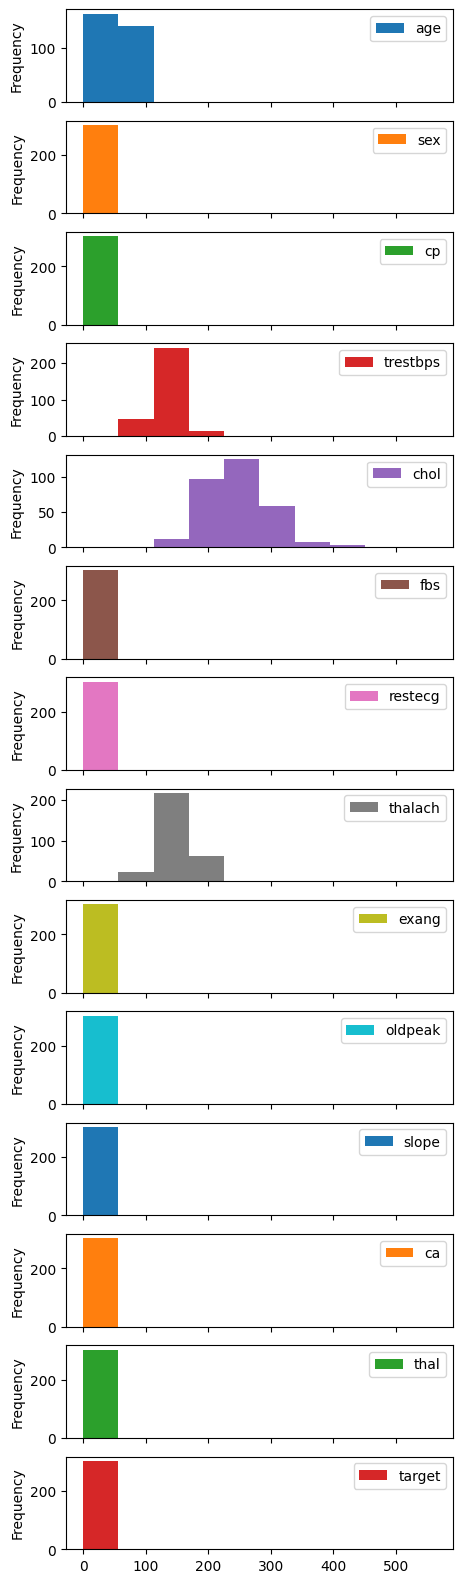

In [83]:
heart_disease.plot.hist(figsize=(5, 20), subplots=True);

### 4. Plotting more advanced plots from a pandas DataFrame

In [86]:
# Perform data analysis on patients over 50
over_50 = heart_disease[heart_disease["age"] > 50]
over_50.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1


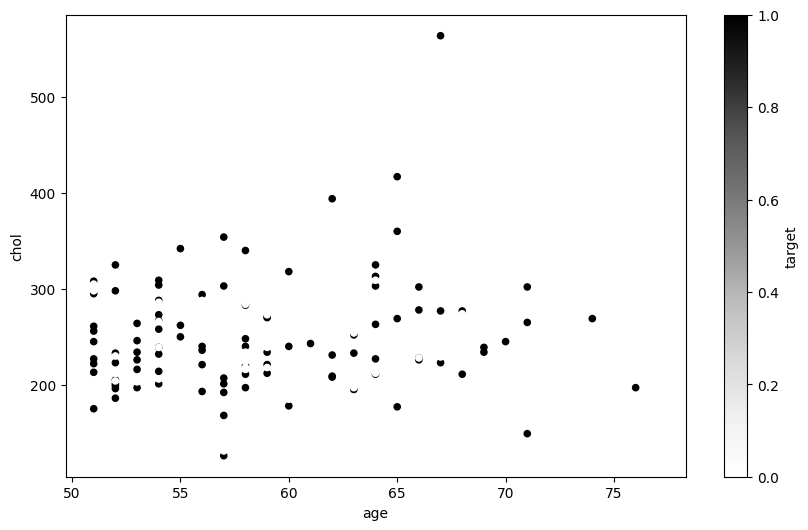

In [87]:
# Create a scatter plot directly from the pandas DataFrame
over_50.plot(kind="scatter",
             x="age", 
             y="chol", 
             c="target",
             figsize=(10, 6));

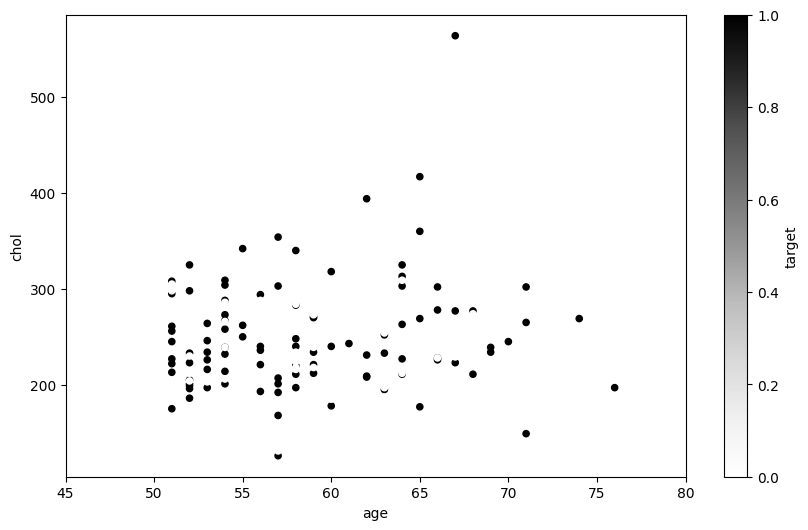

In [91]:
# Create a Figure and Axes instance
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data from the DataFrame to the ax object
over_50.plot(kind="scatter", 
             x="age", 
             y="chol", 
             c="target", 
             ax=ax);

ax.set_xlim([45, 80]);

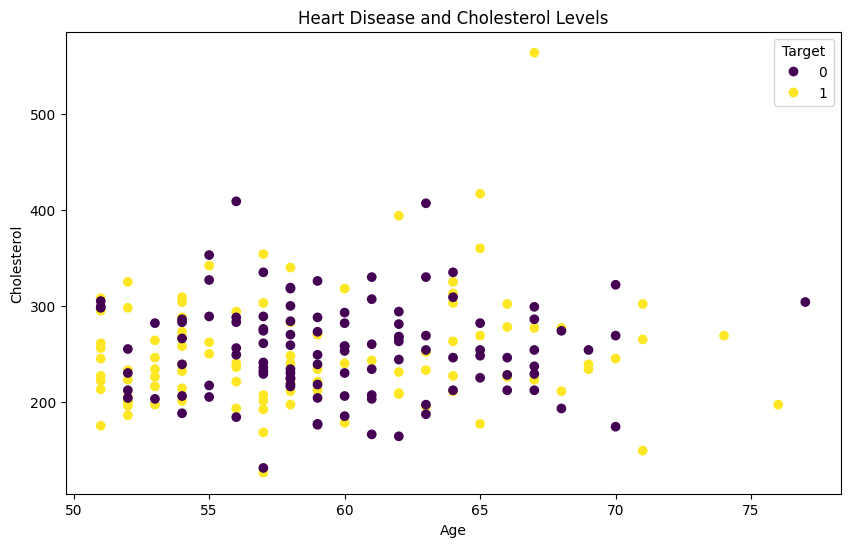

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(over_50['age'], over_50['chol'], c=over_50['target'])
ax.set(title="Heart Disease and Cholesterol Levels", xlabel="Age", ylabel="Cholesterol");

ax.legend(*scatter.legend_elements(), title='Target');

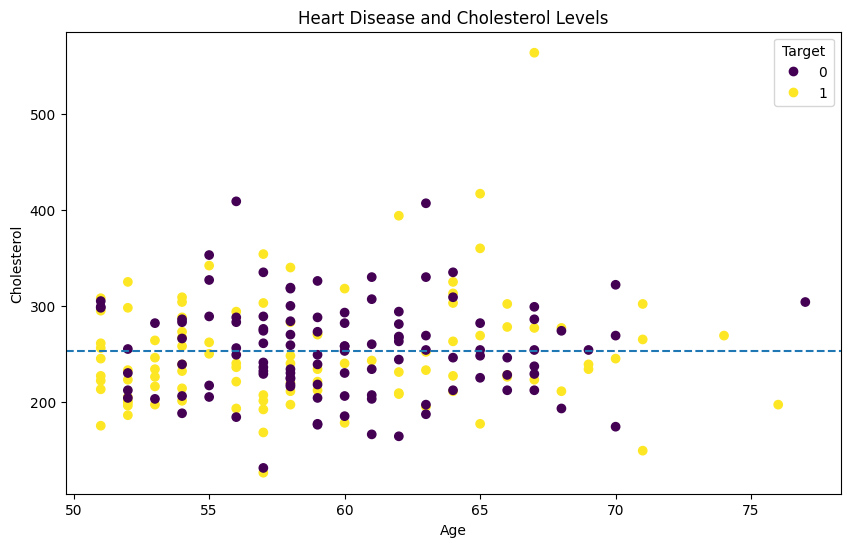

In [99]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(over_50["age"], over_50["chol"], c=over_50["target"])
ax.set(title="Heart Disease and Cholesterol Levels", xlabel="Age", ylabel="Cholesterol");
ax.legend(*scatter.legend_elements(), title="Target")

ax.axhline(over_50["chol"].mean(), linestyle="--");

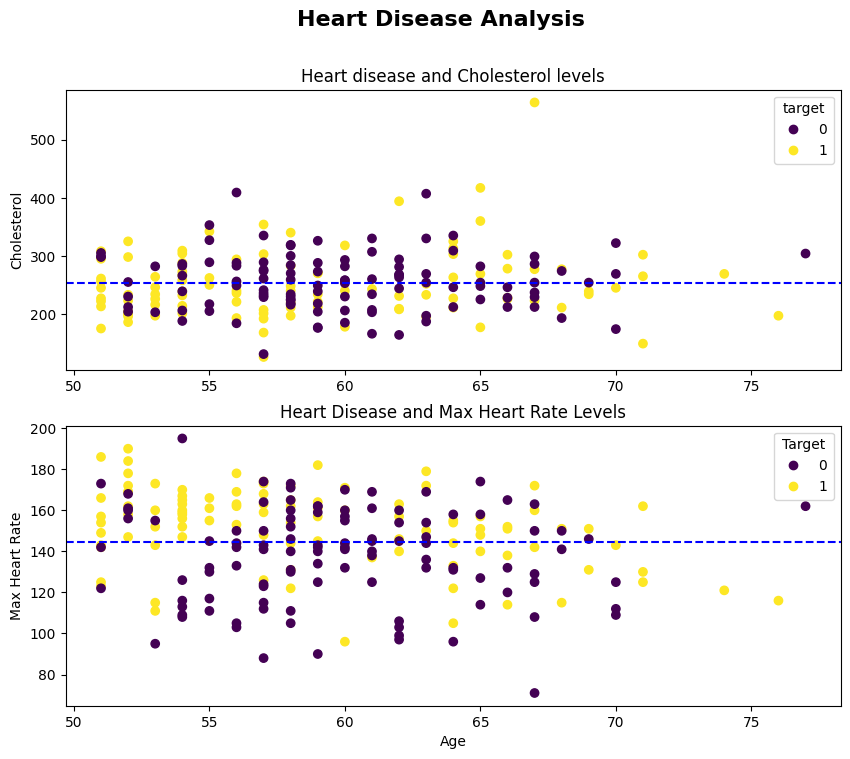

In [126]:
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, figsize=(10,8))

scatter = ax0.scatter(over_50['age'], over_50['chol'], c=over_50['target'])
ax0.set(title='Heart disease and Cholesterol levels', ylabel='Cholesterol')
ax0.legend(*scatter.legend_elements(), title='target')
ax0.axhline(y=over_50['chol'].mean(), color='b', linestyle='--', label='Average')

scatter = ax1.scatter(over_50['age'], over_50['thalach'], c=over_50['target'])
ax1.set(title="Heart Disease and Max Heart Rate Levels", xlabel="Age", ylabel="Max Heart Rate")
ax1.legend(*scatter.legend_elements(), title="Target")
ax1.axhline(y=over_50["thalach"].mean(), color='b', linestyle='--', label="Average")

fig.suptitle('Heart Disease Analysis', fontsize=16, fontweight='bold');

### 5. Customizing your plots (making them look pretty)

In [127]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

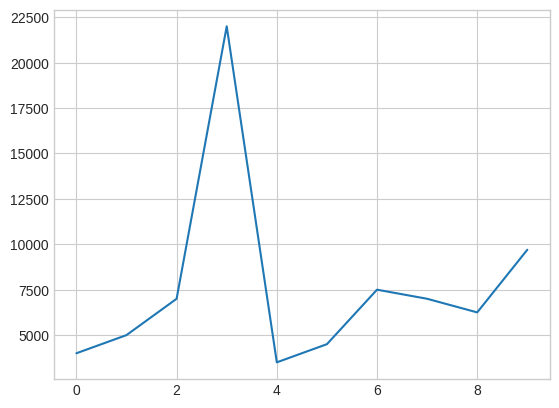

In [130]:
plt.style.use("seaborn-v0_8-whitegrid")

# Plot the same plot as before
car_sales["Price"].plot();

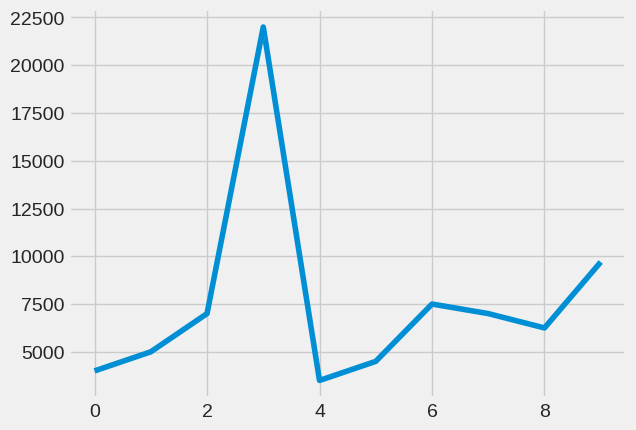

In [132]:
plt.style.use("fivethirtyeight")
car_sales["Price"].plot();

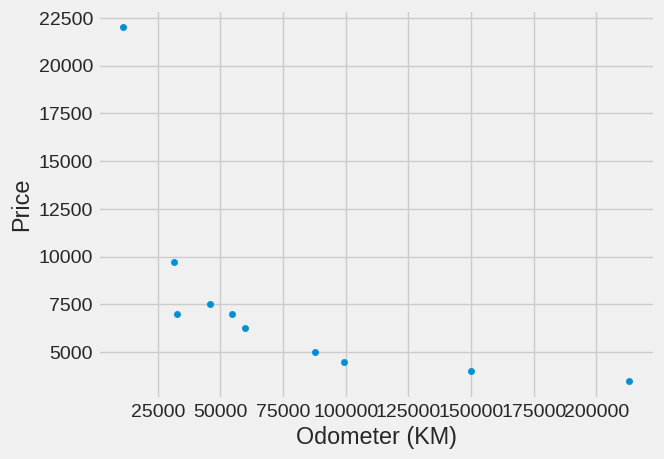

In [133]:
car_sales.plot(x="Odometer (KM)", y="Price", kind="scatter");

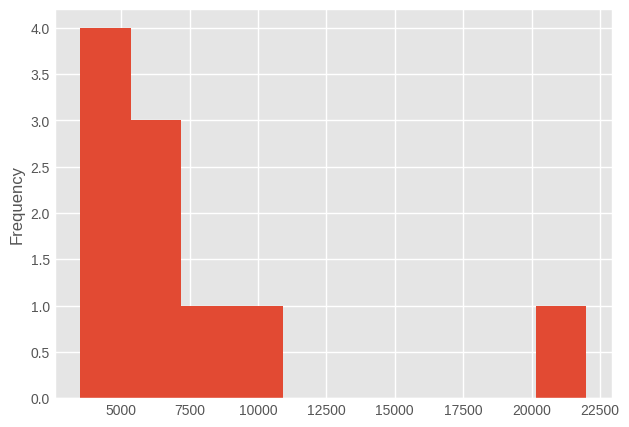

In [134]:
plt.style.use("ggplot")
car_sales["Price"].plot.hist(bins=10);

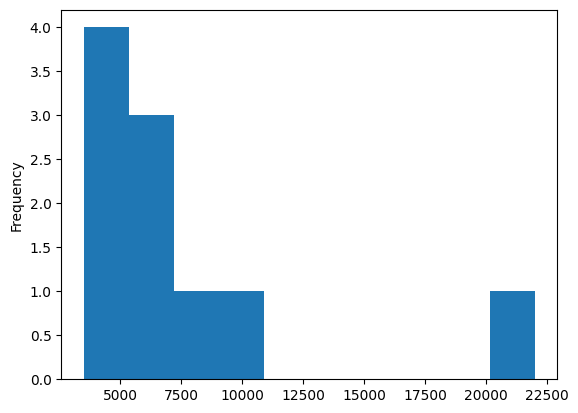

In [135]:
# Change the plot style back to the default 
plt.style.use("default")
car_sales["Price"].plot.hist();

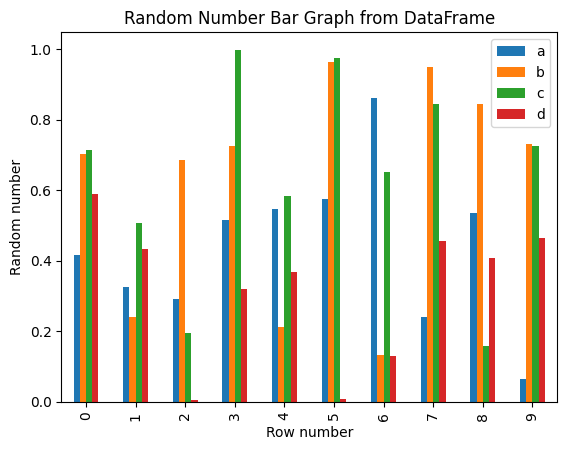

In [136]:
# Recreate the ax object
ax = df.plot(kind="bar")

# Set various attributes
ax.set(title="Random Number Bar Graph from DataFrame", xlabel="Row number", ylabel="Random number");

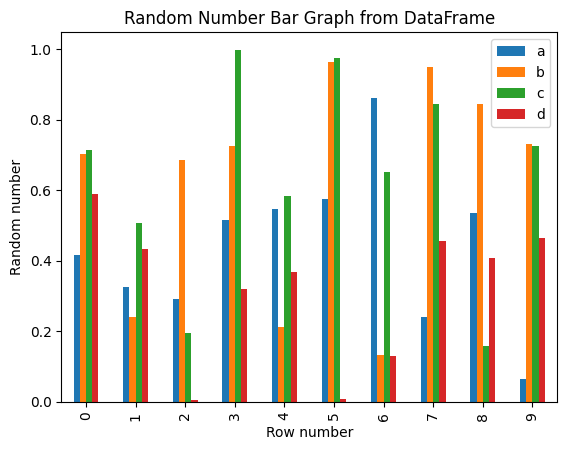

In [137]:
# Recreate the ax object
ax = df.plot(kind="bar")

# Set various attributes
ax.set(title="Random Number Bar Graph from DataFrame", xlabel="Row number", ylabel="Random number")

# Change the legend position
ax.legend(loc="upper right");

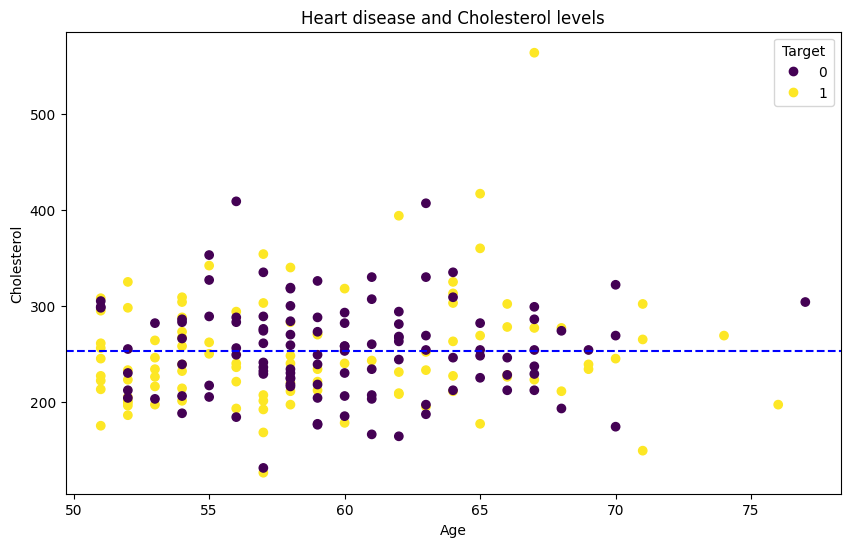

In [144]:
fig, ax = plt.subplots(figsize=(10,6))

scatter = ax.scatter(over_50['age'], over_50['chol'], c=over_50['target'], cmap='viridis')
ax.set(title='Heart disease and Cholesterol levels', xlabel='Age', ylabel='Cholesterol');
ax.axhline(y=over_50['chol'].mean(), c='b', linestyle='--', label='Average');
ax.legend(*scatter.legend_elements(), title='Target');

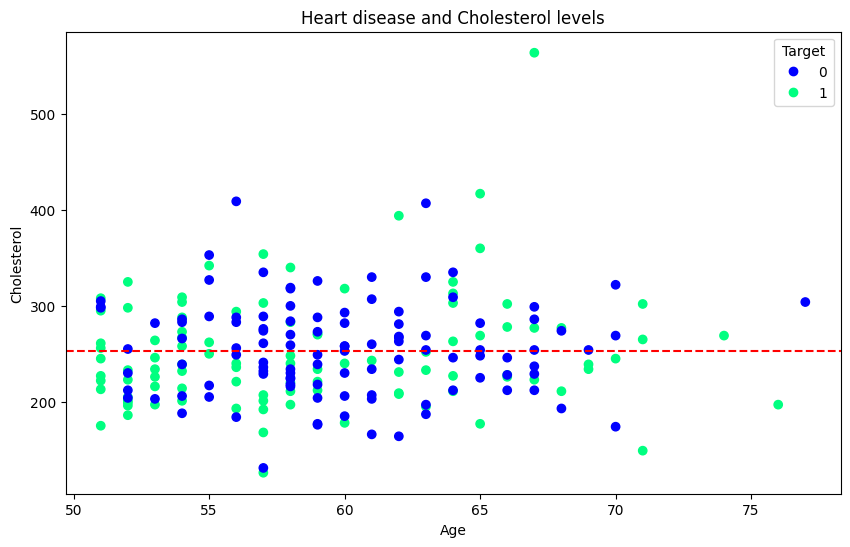

In [147]:
fig, ax = plt.subplots(figsize=(10,6))

scatter = ax.scatter(over_50['age'], over_50['chol'], c=over_50['target'], cmap='winter')
ax.set(title='Heart disease and Cholesterol levels', xlabel='Age', ylabel='Cholesterol');
ax.axhline(y=over_50['chol'].mean(), c='r', linestyle='--', label='Average');
ax.legend(*scatter.legend_elements(), title='Target');

### 6. Saving plots

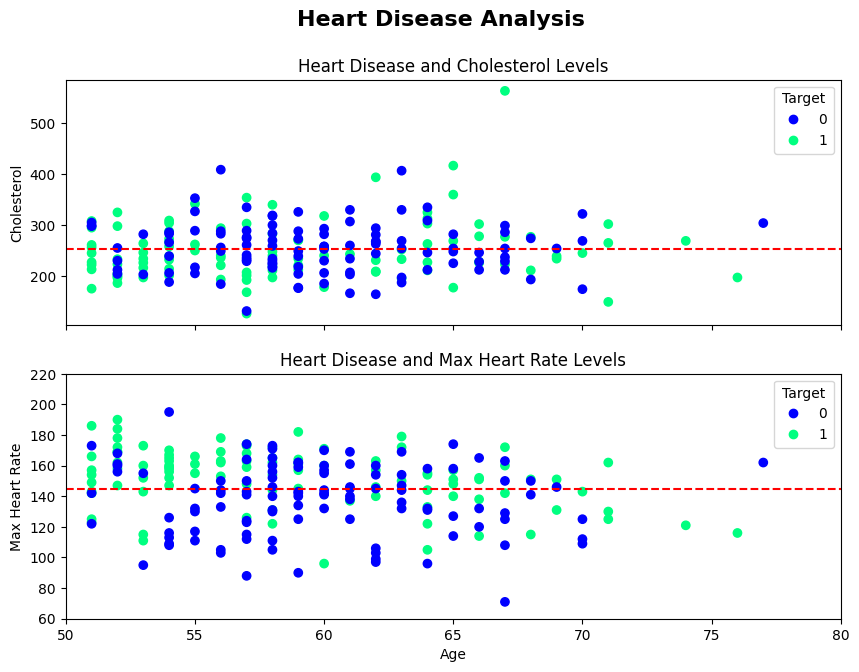

In [159]:
# Recreate the plot from above with custom x and y axis ranges
fig, (ax0, ax1) = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 7))
scatter = ax0.scatter(over_50["age"], over_50["chol"], c=over_50["target"],cmap='winter')
ax0.set(title="Heart Disease and Cholesterol Levels",ylabel="Cholesterol", xlim=[50, 80])

# Setup a mean line
ax0.axhline(y=over_50["chol"].mean(), color="r", linestyle="--", label="Average");
ax0.legend(*scatter.legend_elements(), title="Target")

# Axis 1, 1 (row 1, column 1)
scatter = ax1.scatter(over_50["age"], over_50["thalach"], c=over_50["target"], cmap='winter')
ax1.set(title="Heart Disease and Max Heart Rate Levels", xlabel="Age", ylabel="Max Heart Rate", ylim=[60, 220])

# Setup a mean line
ax1.axhline(y=over_50["thalach"].mean(), color="r", linestyle="--", label="Average");
ax1.legend(*scatter.legend_elements(), title="Target")

# Title the figure
fig.suptitle("Heart Disease Analysis", fontsize=16, fontweight="bold");

In [160]:
fig.canvas.get_supported_filetypes()

{'eps': 'Encapsulated Postscript',
 'jpg': 'Joint Photographic Experts Group',
 'jpeg': 'Joint Photographic Experts Group',
 'pdf': 'Portable Document Format',
 'pgf': 'PGF code for LaTeX',
 'png': 'Portable Network Graphics',
 'ps': 'Postscript',
 'raw': 'Raw RGBA bitmap',
 'rgba': 'Raw RGBA bitmap',
 'svg': 'Scalable Vector Graphics',
 'svgz': 'Scalable Vector Graphics',
 'tif': 'Tagged Image File Format',
 'tiff': 'Tagged Image File Format',
 'webp': 'WebP Image Format'}

In [167]:
fig.savefig(fname="data/heart-disease-analysis.png",dpi=100)

<img src="data/heart-disease-analysis.png" alt="a plot showing a heart disease analysis comparing the presense of heart disease, cholesterol levels and heart rate on patients over 50"/>